# Visualize Data from the Hyper-Angular Rainbow Polarimeter (HARP2)

**Authors:** Sean Foley (NASA, MSU), Meng Gao (NASA, SSAI), Ian Carroll (NASA, UMBC)

## Contents

1. [Setup](#1.-Setup)
2. [Get Level-1C Data](#2.-Get-Level-1C-Data)
3. [Understanding Multi-Angle Data](#3.-Understanding-Multi-Angle-Data)
4. [Understanding Polarimetry](#4.-Understanding-Polarimetry)

In [1]:
import cartopy.crs as ccrs
import earthaccess
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib import animation
from scipy.ndimage import gaussian_filter1d
from nasa_pace_data_reader import L1, plot

In [2]:
auth = earthaccess.login(persist=True)

[back to top](#Contents)

## 2. Get Level-1C Data

Download a granule of HARP2 Level-1C data, which comes from the collection with short-name "PACE_HARP2_L1C_SCI".
Level-1C corresponds to geolocated imagery.
This means the imagery coming from the satellite has been calibrated and assigned to locations on the Earth's surface.
Note that access might take a while, depending on the speed of your internet connection, and the progress bar will seem frozen because we're only looking at one file.

In [3]:
results = earthaccess.search_data(
    short_name="PACE_HARP2_L1C_SCI",
    # temporal=("2025-07-06", "2025-07-06"),
    temporal=("2024-07-14T20:20:00", "2024-07-14T21:40:00"),
    count=1
)

In [6]:
files = earthaccess.download(results, "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L1C_SCI")

In [7]:
paths = "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L1C_SCI/PACE_HARP2.20240714T201640.L1C.V3.5km.nc"

prod = xr.open_dataset(paths)
obs = xr.open_dataset(paths, group="observation_data").squeeze()
geo = xr.open_dataset(paths, group="geolocation_data").set_coords(["longitude", "latitude"])
view = xr.open_dataset(paths, group="sensor_views_bands").squeeze()

The `prod` dataset, as usual for OB.DAAC products, contains attributes but no variables. Merge it with the "observation_data" and "geolocation_data", setting latitude and longitude as auxiliary (e.e. non-index) coordinates, to get started.

In [8]:
dataset = xr.merge((prod, obs, geo))
# dataset

[back to top](#Contents)

## 3. Understanding Multi-Angle Data

HARP2 is a multi-spectral sensor, like OCI, with 4 spectral bands. These roughly correspond to green, red, near infrared (NIR), and blue (in that order). HARP2 is also multi-angle. These angles are with respect to the satellite track. Essentially, HARP2 is always looking ahead, looking behind, and everywhere in between. The number of angles varies per sensor. The red band has 60 angles, while the green, blue, and NIR bands each have 10.

In the HARP2 data, the angles and the spectral bands are combined into one axis. I'll refer to this combined axis as HARP2's "channels." Below, we'll make a quick plot both the viewing angles and the wavelengths of HARP2's channels. In both plots, the x-axis is simply the channel index.

Pull out the view angles and wavelengths.

In [9]:
angles = view["sensor_view_angle"]
wavelengths = view["intensity_wavelength"]

### Create a figure with 2 rows and 1 column and a reasonable size for many screens.

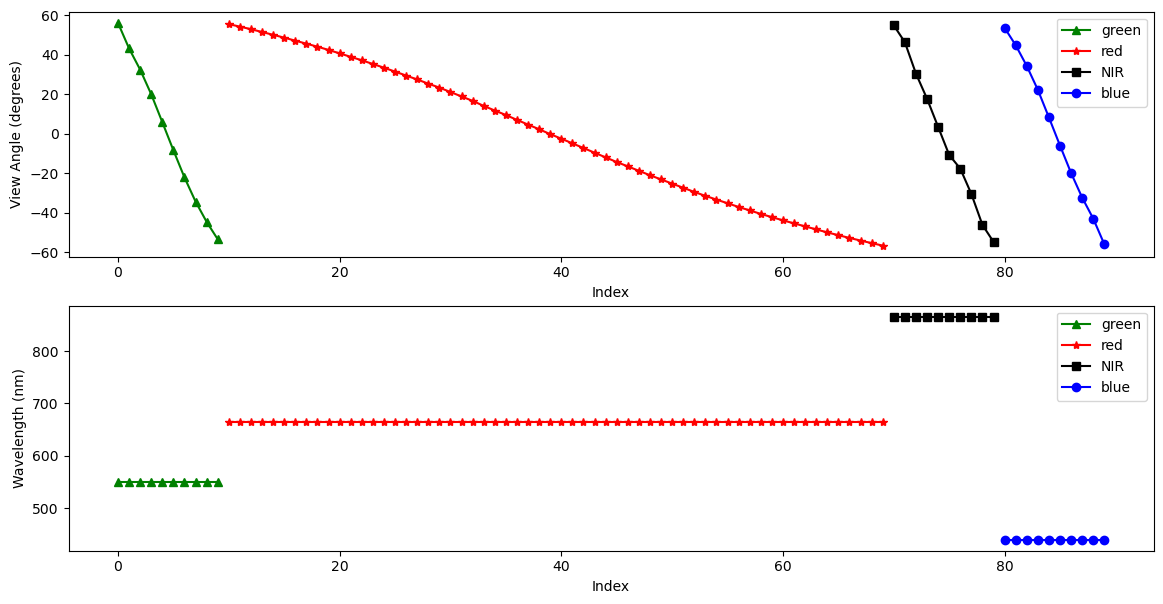

In [10]:
fig, (ax_angle, ax_wavelength) = plt.subplots(2, 1, figsize=(14, 7))
ax_angle.set_ylabel("View Angle (degrees)")
ax_angle.set_xlabel("Index")
ax_wavelength.set_ylabel("Wavelength (nm)")
ax_wavelength.set_xlabel("Index")
plot_data = [
    (0, 10, "green", "^", "green"),
    (10, 70, "red", "*", "red"),
    (70, 80, "black", "s", "NIR"),
    (80, 90, "blue", "o", "blue"),
]
for start_idx, end_idx, color, marker, label in plot_data:
    ax_angle.plot(np.arange(start_idx, end_idx), angles[start_idx:end_idx], color=color, marker=marker,
        label=label,)
    ax_wavelength.plot(np.arange(start_idx, end_idx), wavelengths[start_idx:end_idx], color=color,
        marker=marker, label=label,)
ax_angle.legend()
ax_wavelength.legend()
plt.show()

[back to top](#Contents)

## 4. Understanding Polarimetry

Both HARP2 and SPEXone conduct polarized measurements. Polarization describes the geometric orientation of the oscillation of light waves. Randomly polarized light (like light coming directly from the sun) has an approximately equal amount of waves in every orientation. When light reflects off certain surfaces or is scattered by small particles, it can become non-randomly polarized.

Polarimetric data is typically represented using [Stokes vectors][stokes]. These have four components: I, Q, U, and V. Both HARP2 and SPEXone are only sensitive to linear polarization, and do not detect circular polarization. Since the V component corresponds to circular polarization, the data only includes the I, Q, and U elements of the Stokes vector.

The I, Q, and U components of the Stokes vector are separate variables in the `obs` dataset.

[stokes]: https://en.wikipedia.org/wiki/Stokes_parameters

In [11]:
stokes = dataset[["i", "q", "u"]]

Let's make a plot of the I, Q, and U components of our Stokes vector, using the RGB channels, which will help our eyes make sense of the data. We'll use the view that is closest to pointing straight down, which is called the "nadir" view. It is important to understand that, because HARP2 is a pushbroom sensor with a wide swath, the sensor zenith angle at the edges of the swath will still be high. It's only a true nadir view close to the center of the swath. Still, the average sensor zenith angle will be lowest in this view.)

The first 10 channels are green, the next 60 channels are red, and the final 10 channels are blue (we're skipping NIR).
In each of those groups of channels, we get the index of the minimum absolute value of the camera angle, corresponding to our nadir view.

In [12]:
green_nadir_idx = np.argmin(np.abs(angles[:10].values))
red_nadir_idx = 10 + np.argmin(np.abs(angles[10:70].values))
blue_nadir_idx = 80 + np.argmin(np.abs(angles[80:].values))

print(red_nadir_idx)

39


Then, get the data at the nadir indices.

In [13]:
rgb_stokes = stokes.isel(
    {
        "number_of_views": [red_nadir_idx, green_nadir_idx, blue_nadir_idx],
    }
)

A few adjustments make the image easier to visualize. First, normalize the data between 0 and 1. Second, bring out some of the darker colors.

In [14]:
rgb_stokes = (rgb_stokes - rgb_stokes.min()) / (rgb_stokes.max() - rgb_stokes.min())
rgb_stokes = rgb_stokes ** (3 / 4)

Since the nadir view is not processed at swath edges, a better image will result from finding a valid window within the dataset. Using just the array for the I component, we crop the `rgb_stokes` dataset using the `where` attribute and some boolean logic applied across different dimensions of the array.

In [15]:
window = rgb_stokes["i"].notnull().all("number_of_views")
crop_rgb_stokes = rgb_stokes.where(window.any("bins_along_track") & window.any("bins_across_track"), drop=True,)

Set up the figure and subplots to use a Plate Carree projection.

In [16]:
crs_proj = ccrs.PlateCarree()

The figure will hav 1 row and 3 columns, for each of the I, Q, and U arrays, spanning a width suitable for many screens.

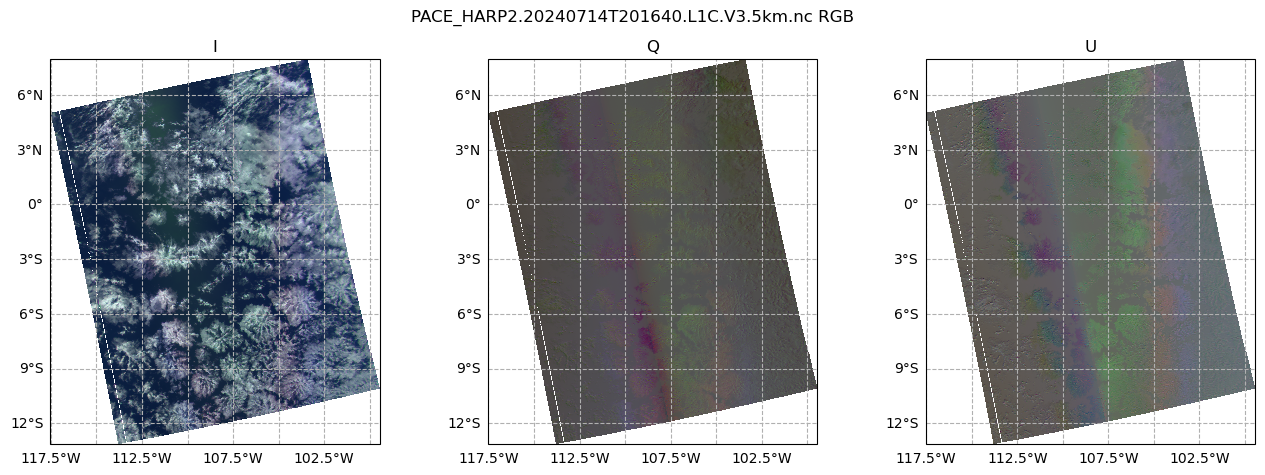

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5), subplot_kw={"projection": crs_proj})
fig.suptitle(f'{prod.attrs["product_name"]} RGB')

for i, (key, value) in enumerate(crop_rgb_stokes.items()):
    ax[i].pcolormesh(value["longitude"], value["latitude"], value, transform=crs_proj)
    ax[i].gridlines(draw_labels={"bottom": "x", "left": "y"}, linestyle="--")
    ax[i].coastlines(color="grey")
    ax[i].set_title(key.upper())

It's pretty plain to see that the I plot makes sense to the eye: we can see clouds over Mexico and the Southwestern United States, with Baja California mostly cloud-free. The I component of the Stokes vector corresponds to the total intensity. In other words, this is roughly what your eyes would see. However, the Q and U plots don't quite make as much sense to the eye. We can see that there is some sort of transition in the middle, which is the satellite track. This transition occurs in both plots, but the differences give us a hint: the type of linear polarization we see in the scene depends on the angle with which we view the scene.

[This Wikipedia plot](https://upload.wikimedia.org/wikipedia/commons/3/31/StokesParameters.png) is very helpful for understanding what exactly the Q and U components of the Stokes vector mean. Q describes how much the light is oriented in -90°/90° vs. 0°/180°, while U describes how much light is oriented in -135°/45°; vs. -45°/135°.

## Next, let's take a look at the Degree of linear polarization (DoLP). 

In [19]:
rgb_dolp = dataset["dolp"].isel(
    {
        "number_of_views": [red_nadir_idx, green_nadir_idx, blue_nadir_idx],
    }
)
rgb_dolp = (rgb_dolp - rgb_dolp.min()) / (rgb_dolp.max() - rgb_dolp.min())
crop_rgb_dolp = rgb_dolp.where(
    window.any("bins_along_track") & window.any("bins_across_track"),
    drop=True,
)
crop_rgb = xr.merge((crop_rgb_dolp, crop_rgb_stokes))

Create a figure with 1 row and 2 columns, having a good width for many screens, that will use the projection defined above. For the two columns, we iterate over just the I and DoLP arrays.

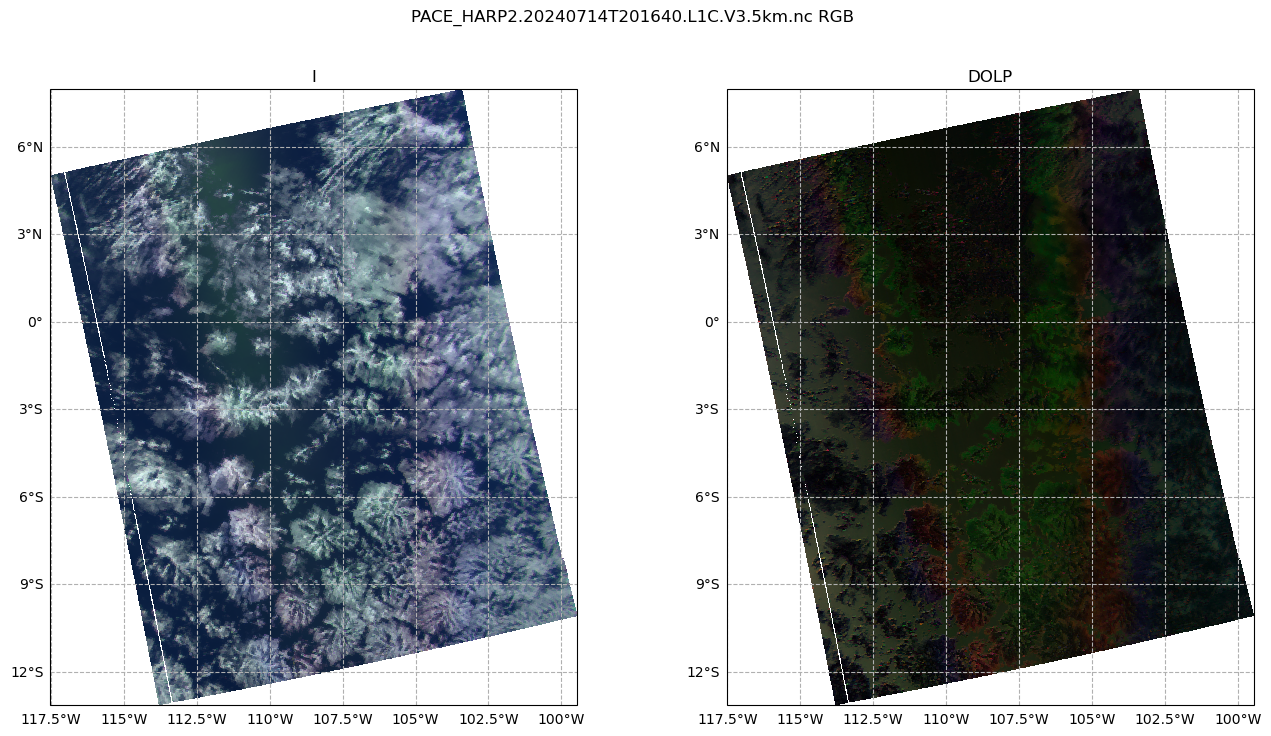

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={"projection": crs_proj})
fig.suptitle(f'{prod.attrs["product_name"]} RGB')

for i, (key, value) in enumerate(crop_rgb[["i", "dolp"]].items()):
    ax[i].pcolormesh(value["longitude"], value["latitude"], value, transform=crs_proj)
    ax[i].gridlines(draw_labels={"bottom": "x", "left": "y"}, linestyle="--")
    ax[i].coastlines(color="grey")
    ax[i].set_title(key.upper())

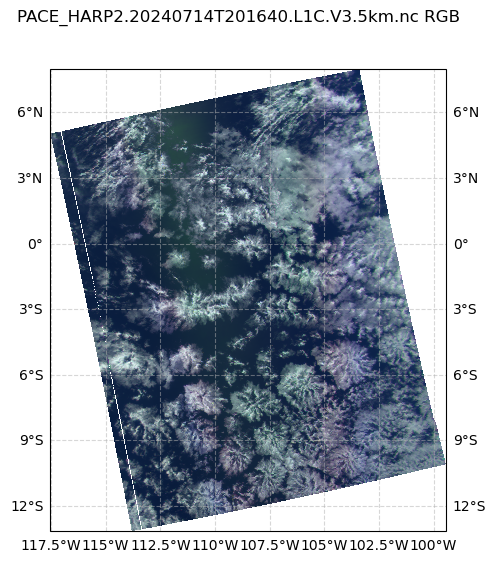

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6), subplot_kw={"projection": crs_proj})
fig.suptitle(f'{prod.attrs["product_name"]} RGB')

value = crop_rgb["i"]
ax.pcolormesh(value["longitude"], value["latitude"], value, transform=crs_proj)
ax.gridlines(draw_labels={"bottom": True, "left": True, "right": True}, linestyle="--", alpha=0.5)
ax.coastlines(color="grey")
plt.savefig('HARP2_RGB.png', dpi=500, bbox_inches="tight")